# Neural Networks: Assignment week 1
Nea Lukumies

Assignment instructions: https://github.com/kopuj/neuralNetworks/blob/master/Assignments/Assignment_week1.md

The data set is fetched using the ucimlrepo library and before doing anything the data is shuffled as the data is originally ordered by class. This way the neural network will have a better chance to learn the patterns in the data instead of just learning the order of the classes. The Keras library is used to build a simple fully connected neural network with one hidden layer. The goal is to achieve at least 95% accuracy on both the training and the validation sets.

In [214]:
import keras
import numpy as np
from keras.models import Sequential
from keras.layers import Input, Dense
from keras.utils import to_categorical
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
from keras.callbacks import LambdaCallback

# fetch dataset 
iris = fetch_ucirepo(id=53) 
  
# data (as pandas dataframes) 
X = iris.data.original
# Shuffle the data
X = X.sample(frac=1, random_state=123).reset_index(drop=True)
X


,sepal length,sepal width,petal length,petal width,class
0,6.3,2.5,4.9,1.5,Iris-versicolor
1,6.8,3.0,5.5,2.1,Iris-virginica
2,6.4,2.8,5.6,2.2,Iris-virginica
3,5.6,3.0,4.1,1.3,Iris-versicolor
4,4.9,3.1,1.5,0.1,Iris-setosa
...,...,...,...,...,...
145,5.1,3.5,1.4,0.3,Iris-setosa
146,5.1,2.5,3.0,1.1,Iris-versicolor
147,5.6,3.0,4.5,1.5,Iris-versicolor
148,6.2,2.8,4.8,1.8,Iris-virginica


After shuffling the data, the target variable ('class') is separated from the features and one-hot encoded. First the classes are encoded as integers and then one-hot encoding is applied to convert the integer labels into a binary matrix representation. This is necessary for multi-class classification problems in neural networks, as it allows the model to output probabilities for each class.

In [215]:
y = X['class']
X = X.drop(columns=['class'])
mapping = {
    "Iris-setosa": 0,
    "Iris-versicolor": 1,
    "Iris-virginica": 2
}

y = [mapping[label] for label in y]
y = to_categorical(y, 3)
print(np.unique(y, axis=0))
print(f"X-shape: {X.shape}, y-shape: {y.shape}")

[[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]
X-shape: (150, 4), y-shape: (150, 3)


The model should as per the instructions consist only of one hidden layer. Before optimizing the model a simple architecture was used with 3 neurons in the hidden layer and the rmsprop optimizer and training with 10 epochs with a 0.2 validation split. This resulted in bad accuracies and even when increasing the number of epochs to 100 the accuracies were still only at about 60-80%. 

The following experimentations were done to try to improve the model (all options were tested with 50 vs.100 epochs):
 - Increasing the number of neurons in the hidden layer to 10
 - Changing the optimizer to Adam
 - Changing batch size to 10
 - Experimenting with different validation splits (0.1-0.3)
 - Changing the learning rate of the optimizer (tested 0.005 and 0.01 when default is 0.001)

In [216]:
# Model definition
model = Sequential([
    Input(shape=(4,)),
    Dense(10, activation='relu'),
    Dense(3, activation='softmax')
])

# Higher learning rate for optimizer
optimizer = keras.optimizers.Adam(learning_rate=0.01) # default is 0.001
# Compile the model
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
print(model.summary())


Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_69 (Dense)                │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83 (332.00 B)

 Trainable params: 83 (332.00 B)

 Non-trainable params: 0 (0.00 B)

None


The final model uses 10 neurons in the hidden layer, Adam optimizer with a learning rate of 0.01, batch size of 10 and a validation split of 0.2. Without tweaking the Adam optimizer the model was fairly good with over 90% accuracies but with the increased learning rate the model was able to achieve over 95% accuracies on both the training and the validation sets.  

There was still some noise in the accuracies that are the result of increasing the learning rate. With a lower learning rate there is less noise (smoother curve), but not the same level of accuracy. A big part of the reason for the noise is also the fact that the data set is small (150 samples) and the model is fairly simple. With a larger data set and adding perhaps just one more hidden layer in the model, the accuracies might be more stable even with a higher learning rate but also, the model might not need a higher learning rate to achieve good accuracies.

The noise means that the accuracies tend to fluctuate between epochs and therefore it might achieve the needed 95% accuracy at some point but the resulting accuracy might have dropped again in the end of the training. To stop the training at the point where the model achieves the needed 95% accuracy, a LambdaCallback was used to monitor the validation accuracy and stop the training when it reaches 95%. This way the model is able to achieve the needed accuracy without overfitting or having the accuracies drop again after reaching the target.

In [217]:
# Stop at 95% val_accuracy
stop_callback = LambdaCallback(
    on_epoch_end=lambda epoch, logs: (
        logs.get('val_accuracy') >= 0.95 and setattr(model, 'stop_training', True)
    )
)

# Train the model
history = model.fit(X, y, epochs=100, batch_size=10, validation_split=0.2, callbacks=[stop_callback])

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2750 - loss: 1.7615 - val_accuracy: 0.0667 - val_loss: 1.2078
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4167 - loss: 1.0216 - val_accuracy: 0.6667 - val_loss: 0.8108
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7000 - loss: 0.7362 - val_accuracy: 0.6667 - val_loss: 0.7012
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6833 - loss: 0.5856 - val_accuracy: 0.7000 - val_loss: 0.5941
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7500 - loss: 0.4924 - val_accuracy: 0.9000 - val_loss: 0.5548
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9083 - loss: 0.4417 - val_accuracy: 0.9333 - val_loss: 0.5073
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8750 - loss: 0.3983 - val_accuracy: 0.8000 - val_loss: 0.4739
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9750 - loss: 0.3667 - val_accuracy: 0.9000 - 

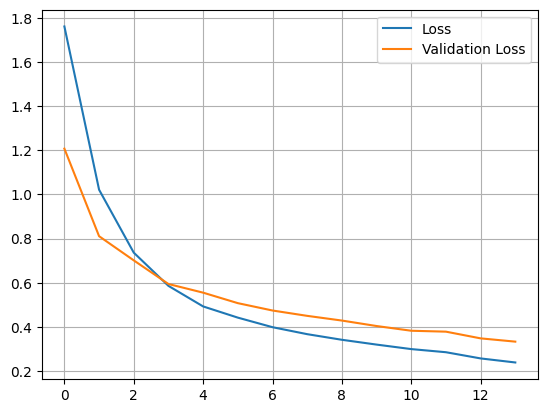

In [218]:
plt.plot(history.history["loss"], label="Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.grid()
plt.show()

After a few runs it would seem that with these settings, the model is achieving the needed accuracies at about 10-20 epochs. Before using this stopping method, the model could achieve the needed accuracies, but the resulting accuracies varied each time the model was trained and therefore it was not guaranteed that the model would achieve the needed accuracies at the end of the training with the epochs set to 50 or 100. The plot above shows that both the loss and validation loss are still decreasing at the point where the training is stopped, which indicated that the model is not overfitting. Overfitting would be seen as the validation loss starting to increase while the training loss continues to decrease meaning that the model is bad at generalizing to new data. In this case, the model is able to generalize well and achieve the needed accuracies without overfitting.